# **LOS/NLOS Classifier Model**

## **Project Setup**

### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from scipy import stats

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [2]:
dataset_path = "../dataset/"  # Dataset directory

csv_files = [
    f for f in os.listdir(dataset_path) if f.endswith(".csv")
]  # Retrieve all csv files in the dataset folder

print(csv_files)  # print out all the csv file name in the 'dataset' folder

# Load and print out dataset values
dfs = []
for file in csv_files:
    print(f"Reading file: {file}")  # Print the file name being read
    df_temp = pd.read_csv(os.path.join(dataset_path, file))  # Read the CSV file
    # print(df_temp)  # Print the entire data of the current CSV file
    dfs.append(df_temp)  # Append the DataFrame to the list

df = pd.concat(
    dfs, ignore_index=True
)  # combining all datasets (csv) files into one DataFrame
print(df)

['uwb_dataset_part2.csv', 'uwb_dataset_part3.csv', 'uwb_dataset_part1.csv', 'uwb_dataset_part4.csv', 'uwb_dataset_part5.csv', 'uwb_dataset_part7.csv', 'uwb_dataset_part6.csv']
Reading file: uwb_dataset_part2.csv
Reading file: uwb_dataset_part3.csv
Reading file: uwb_dataset_part1.csv
Reading file: uwb_dataset_part4.csv
Reading file: uwb_dataset_part5.csv
Reading file: uwb_dataset_part7.csv
Reading file: uwb_dataset_part6.csv
       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09 

Reading the shape and columns of the dataframe provides information on all the data.

In [3]:
# 'df' variable => combine all dataframe into one
print(
    "Number of rows and Column in dataset:", df.shape
)  # shape of the datasets (the total columns and rolls -> matrix[columns,rows])
print(
    "Number of rows in dataset:", df.columns
)  # total columns/attribute in the all datasets

print(
    "number of records in overall datasets:", len(df)
)  # Print the number of records in the all datasets

Number of rows and Column in dataset: (42000, 1031)
Number of rows in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)
number of records in overall datasets: 42000


## **Data Preparation (Data Cleaning & Data Preprocessing)**

### **Data Cleaning for NaN values**

For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_clean.

1. Check and Handle Missing Values

In [4]:
# Calculate the missing values for each column
MissingValCount = df.isnull().sum()

# If there are missing values, drop them and create a new cleaned dataset
if MissingValCount.sum() > 0:
    df_clean = df.dropna()  # Drop rows with missing values
    print(f"Total missing values found and removed: {MissingValCount.sum()} rows dropped.")
else:
    df_clean = df.copy()  # If no missing values, just copy the original dataset
    print("No missing values found in datasets")


No missing values found in datasets


2. Display Dataset Shape Before and After Cleaning

In [5]:
# Display the shape of the dataset before and after cleaning
print("Before cleaning, dataset rows and columns:", df.shape)
print("After cleaning, dataset rows and columns:", df_clean.shape)

# Check if there is a difference in rows or columns
if df.shape == df_clean.shape:
    print("The number of rows and columns are the same in both datasets.")
else:
    rows_diff = df.shape[0] - df_clean.shape[0]
    cols_diff = df.shape[1] - df_clean.shape[1]
    print(
        "The number of rows and columns are different between the original and cleaned datasets.",
        f"Rows difference: {rows_diff}, Columns difference: {cols_diff}",
    )

Before cleaning, dataset rows and columns: (42000, 1031)
After cleaning, dataset rows and columns: (42000, 1031)
The number of rows and columns are the same in both datasets.


### **Data Visualization and Data Cleaning**

Next, we will perform data visualization to better understand the features and their relationships. Visualizing the data helps in identifying patterns, trends, and potential outliers.

In [6]:
# import libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


#### **Target Variable: NLOS**

The pie chart below illustrates the count for **NLOS** with labels 0.0 and 1.0. From the graph, we can observe that the distribution is balanced, with an equal count of 0.0 and 1.0 labels.

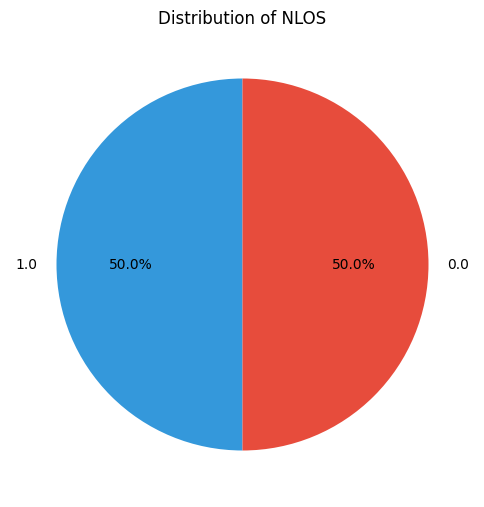

In [7]:
# count the total in NLOS attribute in the datasets
count_NLOS = df_clean["NLOS"].value_counts()

# visualization to show the distributionfor the 'NLOS' attribute
plt.figure(figsize=(6, 10))
count_NLOS.plot.pie(autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
plt.title("Distribution of NLOS")
plt.ylabel("")
plt.show()

#### **Target Variable: FP_IDX**

The box plot graph below illustrates tcompares the distribution of FP_IDX values between LOS and NLOS, Showing any differences in their statistical properties. 

From the graph, it shows the spread of FP_IDX for both LOS and NLOS. NLOS has an outlier, indicating a potential anomaly

##### **Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR, Identify and Filter Outliers

In [8]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for FP_IDX
Q1 = df_clean["FP_IDX"].quantile(0.25)
Q3 = df_clean["FP_IDX"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in FP_IDX based on the bounds
outliers = df_clean[
    (df_clean["FP_IDX"] < lower_bound) | (df_clean["FP_IDX"] > upper_bound)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers)

# Filter out outliers separately for LOS and NLOS
# For LOS (Line of Sight)
df_clean_filtered_LOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 0.0)  # LOS condition
]

# For NLOS (Non-Line of Sight)
df_clean_filtered_NLOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 1.0)  # NLOS condition
]

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
26      1.0   4.54   737.0   2066.0   4232.0   3116.0         84.0   3789.0   
31      1.0   8.88   736.0   1823.0   1750.0   1277.0         76.0   4493.0   
46      1.0   5.86   737.0   3448.0   5723.0   3512.0         84.0    953.0   
49      1.0   7.32   734.0   2304.0   1919.0   1957.0         72.0   9314.0   
62      1.0  12.57   731.0   3438.0   1617.0   1713.0         76.0   1596.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41868   1.0   3.39   722.0    711.0   1391.0    829.0         88.0   2237.0   
41869   1.0   7.09   736.0   1501.0   1581.0    969.0         64.0    297.0   
41910   1.0   7.33   736.0    272.0   1719.0   1823.0         88.0   1561.0   
41969   1.0  13.13   727.0    719.0   1209.0   1395.0         88.0    924.0   
41982   1.0   4.64   733.0   1005.0   2047.0   1514.0         60.0    396.0   

       MAX_NOISE  RXPACC  .

2. Combine Data, Clean Redundant Columns, and Rename

In [9]:
# Combine both cleaned datasets (LOS and NLOS)
df_clean_filtered = pd.concat([df_clean_filtered_LOS, df_clean_filtered_NLOS])

# Remove redundant 'NLOS' column if it exists
if "category" in df_clean_filtered.columns and "NLOS" in df_clean_filtered.columns:
    df_clean_filtered = df_clean_filtered.drop(columns=["NLOS"])

# Rename 'NLOS' column to 'Signal_Path' if it exists
df_clean_filtered = (
    df_clean_filtered.rename(columns={"NLOS": "Signal_Path"})
    if "NLOS" in df_clean_filtered.columns
    else df_clean_filtered
)

After removing the outliners, next we will be filtering the dataset based on **FP_IDX** values within a specified range and adds a new **Category** column that labels the data as **"LOS"** or **"NLOS"** based on the NLOS values.

In [10]:
df_clean_filtered = df_clean[
    (df_clean["FP_IDX"] >= lower_bound) & (df_clean["FP_IDX"] <= upper_bound)
].copy()
# Create a new column to indicate the category (LOS or NLOS)
df_clean_filtered.loc[:, "Category"] = df_clean_filtered["NLOS"].apply(
    lambda x: "LOS" if x == 1.0 else "NLOS"
)

##### **Visualizing the Data**

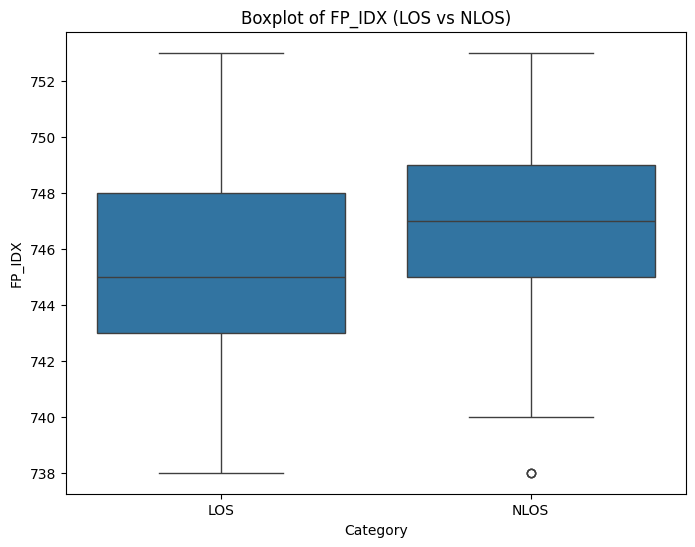

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Category", y="FP_IDX", data=df_clean_filtered)
plt.title("Boxplot of FP_IDX (LOS vs NLOS)")
plt.show()

#### **Target Variable: FP_AMP1, FP_AMP2**, **FP_AMP3**

##### **Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

For FP_AMP1, 

In [12]:
# Calculate the Range using IQR for FP_AMP1
Q1_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.25)
Q3_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.75)
IQR_FP_AMP1 = Q3_FP_AMP1 - Q1_FP_AMP1
lower_bound_FP_AMP1 = Q1_FP_AMP1 - 1.5 * IQR_FP_AMP1
upper_bound_FP_AMP1 = Q3_FP_AMP1 + 1.5 * IQR_FP_AMP1

# Identify outliers
outliers_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] < lower_bound_FP_AMP1)
    | (df_clean["FP_AMP1"] > upper_bound_FP_AMP1)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] >= lower_bound_FP_AMP1)
    & (df_clean["FP_AMP1"] <= upper_bound_FP_AMP1)
]

# Print outliers
print("Outliers for 'FP_AMP1':\n", outliers_FP_AMP1)

Outliers for 'FP_AMP1':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP2 ,

In [13]:
# Calculate the Range using IQR for FP_AMP2
Q1_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.25)
Q3_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.75)
IQR_FP_AMP2 = Q3_FP_AMP2 - Q1_FP_AMP2
lower_bound_FP_AMP2 = Q1_FP_AMP2 - 1.5 * IQR_FP_AMP2
upper_bound_FP_AMP2 = Q1_FP_AMP2 + 1.5 * IQR_FP_AMP2

# Identify outliers
outliers_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] < lower_bound_FP_AMP2)
    | (df_clean["FP_AMP2"] > upper_bound_FP_AMP2)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] >= lower_bound_FP_AMP2)
    & (df_clean["FP_AMP2"] <= upper_bound_FP_AMP2)
]

# Print outliers
print("Outliers for 'FP_AMP2':\n", outliers_FP_AMP2)

Outliers for 'FP_AMP2':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP3 ,

In [14]:
# Calculate the Range using IQR for FP_AMP3
Q1_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.25)
Q3_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.75)
IQR_FP_AMP3 = Q3_FP_AMP3 - Q1_FP_AMP3
lower_bound_FP_AMP3 = Q1_FP_AMP3 - 1.5 * IQR_FP_AMP3
upper_bound_FP_AMP3 = Q1_FP_AMP3 + 1.5 * IQR_FP_AMP3

# Identify outliers
outliers_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] < lower_bound_FP_AMP3)
    | (df_clean["FP_AMP3"] > upper_bound_FP_AMP3)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] >= lower_bound_FP_AMP3)
    & (df_clean["FP_AMP3"] <= upper_bound_FP_AMP3)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers_FP_AMP3)

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
104     0.0   5.08   745.0   2922.0  15891.0  19129.0         80.0   9962.0   
123     0.0   1.40   750.0  16026.0  20343.0  19026.0         52.0  12543.0   
145     0.0   5.69   746.0   4278.0  17974.0  20245.0         48.0   9526.0   
185     0.0   1.98   746.0  12539.0  20207.0  19131.0         52.0  15467.0   
365     1.0   6.91   746.0   2318.0  19454.0  20296.0         60.0  23903.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41757   1.0   0.54   751.0   7203.0  19603.0  19507.0        160.0  11759.0   
41829   0.0   4.74   748.0   9000.0  15539.0  19426.0         68.0  10231.0   
41843   0.0   3.47   744.0   7574.0  19104.0  20218.0         52.0  11691.0   
41904   0.0   2.05   749.0   7766.0  18756.0  19044.0         60.0   9430.0   
41953   0.0   0.98   745.0  12354.0  11519.0  19650.0         48.0  15739.0   

       MAX_NOISE  RXPACC  .

After removing the outliers, we combine FP_AMP1, FP_AMP2, and FP_AMP3 into one DataFrame

In [15]:
# Combining multiplte dataframe in to one DataFrame
df_filtered = pd.DataFrame(
    {
        "FP_AMP1": df_clean_filtered_FP_AMP1["FP_AMP1"],
        "FP_AMP2": df_clean_filtered_FP_AMP2["FP_AMP2"],
        "FP_AMP3": df_clean_filtered_FP_AMP3["FP_AMP3"],
    }
)

# Reshape the data for the violin plot
df_filtered_melted = df_filtered.melt(var_name="Feature", value_name="Value")
print(
    "This Graph shows thatUsed to show the spread and median of FP_AMP1, FP_AMP2, and FP_AMP3, as their ranges are similar."
)
print(
    "Conclusion: FP_AMP1, FP_AMP2, and FP_AMP3 have similar ranges, spread, and median. However, the median and spread for FP_AMP1 are slightly higher than the other two."
)

This Graph shows thatUsed to show the spread and median of FP_AMP1, FP_AMP2, and FP_AMP3, as their ranges are similar.
Conclusion: FP_AMP1, FP_AMP2, and FP_AMP3 have similar ranges, spread, and median. However, the median and spread for FP_AMP1 are slightly higher than the other two.


##### **Visualizing the Data**

After combining all into one DataFrame, we will plot a **violin graph** to illustrate the spread and median of **FP_AMP1**, **FP_AMP2**, and **FP_AMP3**, as their ranges are similar.

From the graph, we can see that these features have similar ranges, spread, and median. However, the median and spread for **FP_AMP1** are slightly higher than those of **FP_AMP2** and **FP_AMP3**, suggesting that **FP_AMP1** has slightly more variation or a higher central tendency compared to the other two.

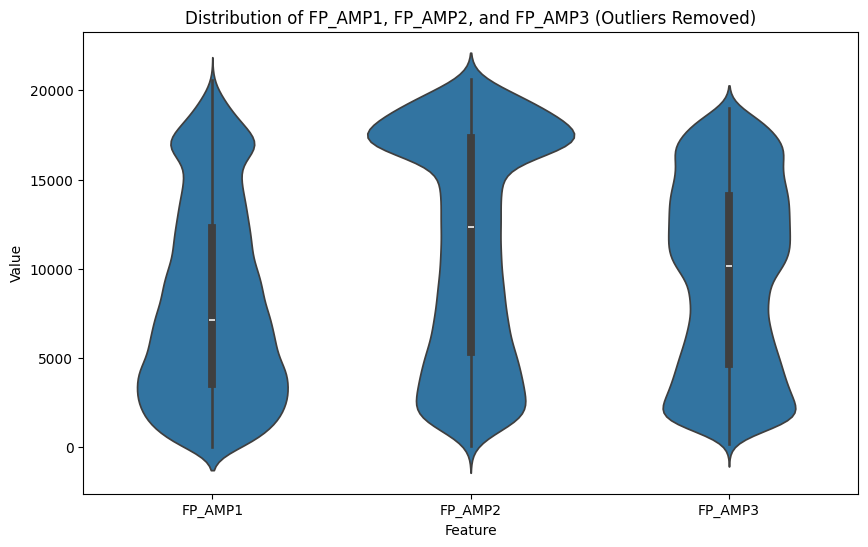

In [16]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Feature", y="Value", data=df_filtered_melted)

plt.title("Distribution of FP_AMP1, FP_AMP2, and FP_AMP3 (Outliers Removed)")
plt.show()

#### **Target Variable: STDEV_NOISE**


For **STDEV_NOISE**, we will plot a strip plot to gain a better understanding of the distribution. The strip plot below illustrates the distribution of **STDEV_NOISE** with labels 0.0 and 1.0.

From the graph, we can observe that the 0.0 label has a lower **STDEV_NOISE** value compared to 1.0, indicating that the noise is more consistent in **LOS** (Line-of-Sight) than in **NLOS** (Non-Line-of-Sight).

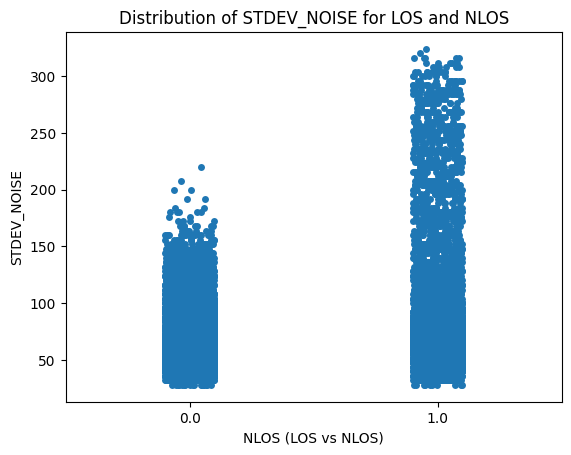

In [17]:
sns.stripplot(data=df_clean, x="NLOS", y="STDEV_NOISE", jitter=True)
plt.title("Distribution of STDEV_NOISE for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("STDEV_NOISE")
plt.show()

#### **Target Variable: CIR_PWR**

##### **Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR and Identify Outliers

In [18]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for CIR_PWR
Q1_CIR_PWR = df_clean["CIR_PWR"].quantile(0.25)
Q3_CIR_PWR = df_clean["CIR_PWR"].quantile(0.75)

# Calculate the Interquartile Range (IQR) for CIR_PWR
IQR_CIR_PWR = Q3_CIR_PWR - Q1_CIR_PWR

# Calculate lower and upper bounds for outliers
lower_bound_CIR_PWR = Q1_CIR_PWR - 1.5 * IQR_CIR_PWR
upper_bound_CIR_PWR = Q3_CIR_PWR + 1.5 * IQR_CIR_PWR

# Identify outliers in CIR_PWR based on the calculated bounds
outliers_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] < lower_bound_CIR_PWR) | (df_clean["CIR_PWR"] > upper_bound_CIR_PWR)
]


2. Filter and Clean Data

In [19]:
# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] >= lower_bound_CIR_PWR) & (df_clean["CIR_PWR"] <= upper_bound_CIR_PWR)
]

# Print outliers
print("Outliers for 'CIR_PWR':\n", outliers_CIR_PWR)


Outliers for 'CIR_PWR':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
34      1.0   6.35   746.0  11146.0  10502.0   6624.0         60.0  21115.0   
56      0.0   2.12   747.0  13091.0  16349.0  11204.0        120.0  29570.0   
67      1.0   6.31   750.0  13805.0  19543.0  11380.0         64.0  31759.0   
71      1.0   6.68   745.0  13068.0   9016.0   5174.0         68.0  23124.0   
75      0.0   5.96   748.0  12532.0   8788.0  15810.0        128.0  25006.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41748   1.0   7.64   744.0    248.0  14006.0  12489.0         64.0  22825.0   
41834   0.0   5.09   750.0   8443.0  16866.0  11160.0         68.0  21287.0   
41871   0.0   3.07   746.0   5715.0  10261.0  12889.0         84.0  29942.0   
41922   0.0   1.67   746.0  10780.0  18043.0  14167.0        136.0  26737.0   
41974   1.0   7.59   747.0    108.0  17802.0  17768.0         52.0  24454.0   

       MAX_NOISE  RXPACC  

##### **Visualizing the Data**
After removing the outliers, we will plot a histogram to better understand the distribution of **CIR_PWER** values. T

The histogram below illustrates the spread of values for **CIR_PWER** with labels 0.0 and 1.0. Based on this graph, we can see that the distributions for XLOS and NLOS statuses are similar for **CIR_PWER**, but **NLOS (1.0)** has a wider spread of values.

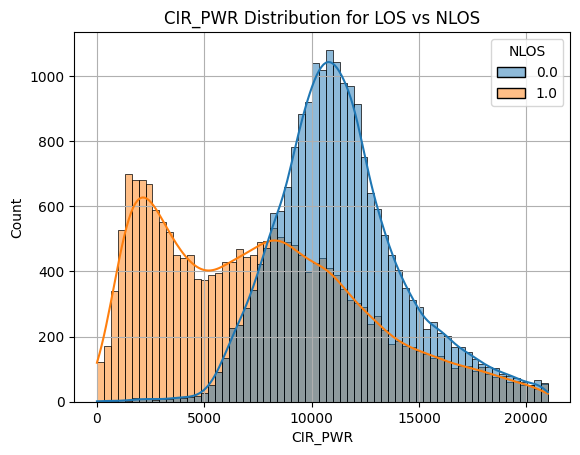

In [20]:
sns.histplot(data=df_clean_filtered_CIR_PWR, x="CIR_PWR", hue="NLOS", kde=True)
plt.title("CIR_PWR Distribution for LOS vs NLOS")
plt.xlabel("CIR_PWR")
plt.ylabel("Count")
plt.grid(True)
plt.show()

#### **Target Variable: MAX_NOISE**

For MAX_NOISE, we will plot a violin plot to better understand the distribution and observe the variation in noise. The plot below illustrates the distribution of MAX_NOISE with labels 0.0 and 1.0.

From the graph, we can observe how the noise varies between LOS (Line-of-Sight) and NLOS (Non-Line-of-Sight), highlighting the differences in their noise patterns.

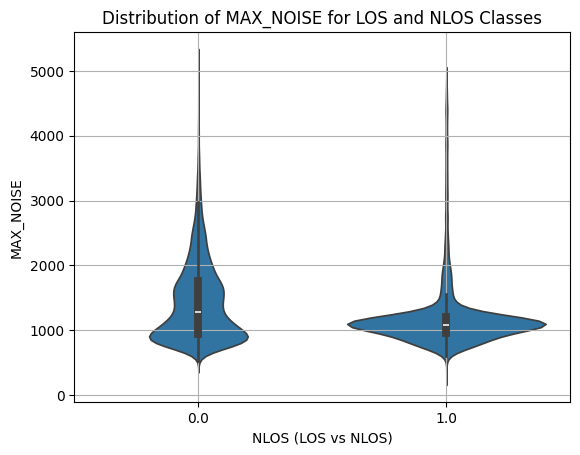

In [21]:
# df_clean_filtered = df_clean[
#     (df_clean["MAX_NOISE"] >= 500) & (df_clean["MAX_NOISE"] < 1100)
# ]

sns.violinplot(data=df_clean_filtered, x="NLOS", y="MAX_NOISE")
plt.title("Distribution of MAX_NOISE for LOS and NLOS Classes")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("MAX_NOISE")
plt.grid(True)
plt.show()

#### **Target Variable: RXPACC**

##### **Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

1. Identify Outliers Using IQR for RXPACC

In [22]:
# Filter the data based on specific RXPACC values (between 500 and 1100)
df_clean_filtered_RXPACC = df_clean[
    (df_clean["RXPACC"] >= 500) & (df_clean["RXPACC"] < 1100)
]

Next, we will remove columns that are not necessary for plotting the graph. This will help streamline the dataset, ensuring that we only work with the relevant features needed for visualization.

In [23]:
# List of columns to exclude
columns_to_exclude = [
    "NLOS",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
]

# remove the CIR_[Number] columns using regex
columns_to_exclude += [col for col in df_clean.columns if col.startswith("CIR")]
df_clean_copy = df_clean.drop(columns=columns_to_exclude)

print(df_clean_copy)

       RANGE  STDEV_NOISE   CH  FRAME_LEN  PREAM_LEN  BITRATE  PRFR
0       6.18        240.0  2.0       39.0     1024.0    110.0  64.0
1       4.54         68.0  2.0       39.0     1024.0    110.0  64.0
2       4.39         52.0  2.0       27.0     1024.0    110.0  64.0
3       1.27         64.0  2.0       39.0     1024.0    110.0  64.0
4       1.16         76.0  2.0       27.0     1024.0    110.0  64.0
...      ...          ...  ...        ...        ...      ...   ...
41995   4.09         88.0  2.0       27.0     1024.0    110.0  64.0
41996   2.18         44.0  2.0       39.0     1024.0    110.0  64.0
41997   1.25         60.0  2.0       39.0     1024.0    110.0  64.0
41998   3.17         64.0  2.0       39.0     1024.0    110.0  64.0
41999   7.24         60.0  2.0       39.0     1024.0    110.0  64.0

[42000 rows x 7 columns]


##### **Visualizing the Data**

After removing unnecessary columns, the next step is to plot a pairplot to visualize the distribution of **RXPACC** for the **LOS (0.0)** and **NLOS (1.0)** classes. The plot below illustrates how the **RXPACC** values differ between these two classes, with points color-coded by the **NLOS** label.

From the graph, we can observe XXXX

<Figure size 1400x800 with 0 Axes>

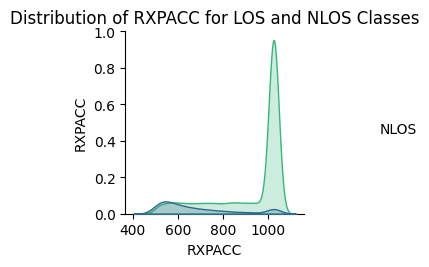

In [24]:
df_plot = df_clean_filtered_RXPACC[["RXPACC", "NLOS"]]
plt.figure(figsize=(14, 8))
sns.pairplot(df_plot, hue="NLOS", palette="viridis", plot_kws={"alpha": 0.7})
plt.title("Distribution of RXPACC for LOS and NLOS Classes")
plt.grid(True)
plt.show()

#### For **FRAME_LEN**

**Count Occurrences of Values**

In [25]:
count_framelen = df_clean["FRAME_LEN"].value_counts()
print(count_framelen)

FRAME_LEN
39.0    23806
27.0    18193
29.0        1
Name: count, dtype: int64


##### **Visualizing the Data**

For **FRAME_LEN**, we will plot a bar chart showing the count distribution, which allows us to see how the values are spread across the dataset. 

From this graph, we can observe the XXX

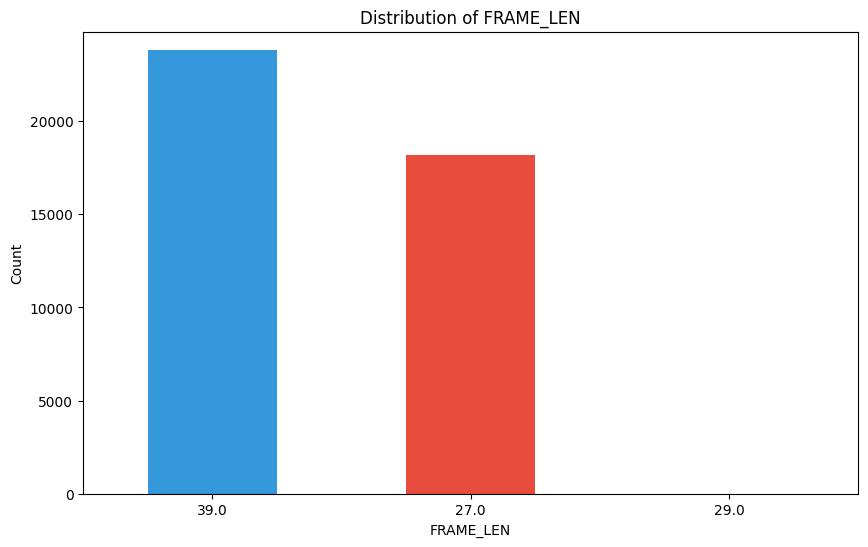

In [26]:
# Plot the distribution
plt.figure(figsize=(10, 6))
count_framelen.plot.bar(
    color=["#3498db", "#e74c3c", "#f39c12"]
)  # Optional color customization
plt.title("Distribution of FRAME_LEN")
plt.ylabel("Count")
plt.xlabel("FRAME_LEN")
plt.xticks(rotation=0)

# Adjust y-axis to ensure all values are visible
plt.yscale(
    "linear"
)  # Ensures that the scale is linear and smaller values show up properly
plt.ylim(0, count_framelen.max() + 1000)  # Extend the y-axis a bit to give space

plt.show()

#### For **PREAM_LEN**

##### **Visualizing the Data**

For **PREAM_LEN**, we will plot a bar chart showing the count distribution which allows us to see how the values are spread across the dataset.

From this graph, XXX

**Count Occurrences of Values**

In [27]:
# Count occurrences of 'PREAM_LEN' values
count_PREAM_LEN = df_clean["PREAM_LEN"].value_counts()
print(count_PREAM_LEN)

PREAM_LEN
1024.0    40443
1536.0     1557
Name: count, dtype: int64


##### **Visualizing the Data**

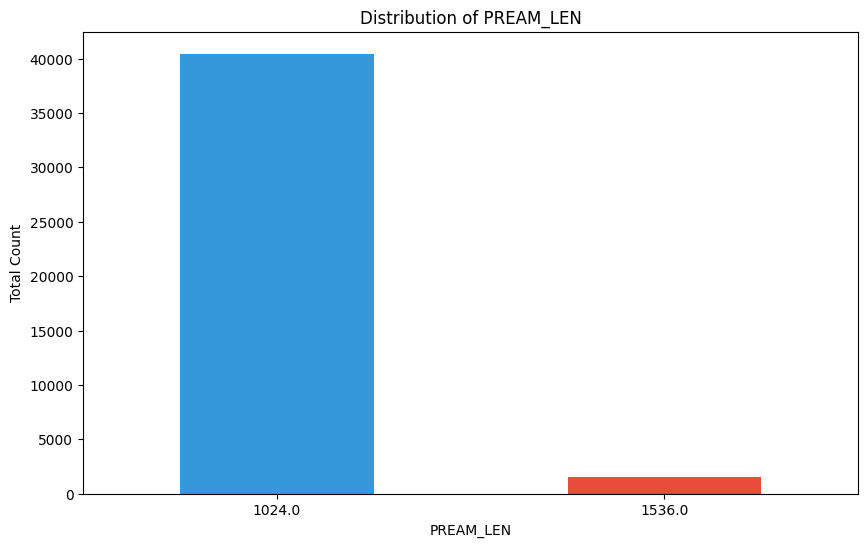

In [28]:
# Plot the distribution
plt.figure(figsize=(10, 6))
count_PREAM_LEN.plot.bar(color=["#3498db", "#e74c3c"])
plt.title("Distribution of PREAM_LEN")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

#### **Feature Importance**

First, we extract the feature importance from the trained RandomForest model, which indicates the contribution of each feature to the model’s predictions. We then store the feature names and their importance values in a DataFrame, sort them by importance, and display the top 20 most important features through a bar plot.

#### For **PRFR** and **BITRATE**

##### **Visualizing the Data**

For **PRFR** and **BITRATE**, the graph will display side-by-side bars showing their total count occurrences. Since the columns have fixed categories, the graph will provide a clear comparison of how each category in **PRFR** and **BITRATE** is distributed.

**Count Occurrences of 'PRFR' and 'BITRATE' Values**

In [29]:
# Count occurrences of 'PRFR' values
count_PRFR = df_clean["PRFR"].value_counts()

# Count occurrences of 'BITRATE' values
count_BITRATE = df_clean["BITRATE"].value_counts()

**Combine and Plot the Distribution of 'PRFR' and 'BITRATE'**

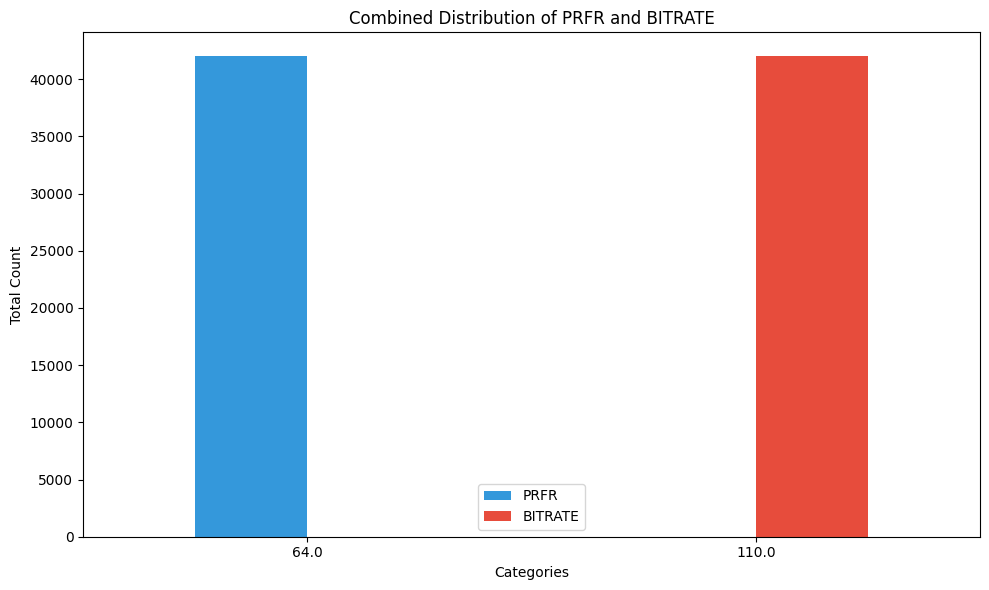

In [30]:
# Combine the counts into a DataFrame
combined_df = pd.DataFrame(
    {"PRFR": count_PRFR, "BITRATE": count_BITRATE, "BITRATE": count_BITRATE}
).fillna(0)

# Plot the combined distribution (side-by-side bars)
combined_df.plot(kind="bar", figsize=(10, 6), color=["#3498db", "#e74c3c"])

# Set plot labels and title
plt.title("Combined Distribution of PRFR and BITRATE")
plt.ylabel("Total Count")
plt.xlabel("Categories")
plt.xticks(rotation=0)  # Keep x-axis labels clear

plt.tight_layout()
plt.show()

#### For **RANGE**

##### **Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

In [31]:
Q1_RANGE = df_clean["RANGE"].quantile(0.25)
Q3_RANGE = df_clean["RANGE"].quantile(0.75)
IQR_RANGE = Q3_RANGE - Q1_RANGE
lower_bound_RANGE = Q1_RANGE - 1.5 * IQR_RANGE
upper_bound_RANGE = Q3_RANGE + 1.5 * IQR_RANGE

# Identify outliers
outliers_RANGE = df_clean[
    (df_clean["RANGE"] < lower_bound_RANGE) | (df_clean["RANGE"] > upper_bound_RANGE)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_RANGE = df_clean[
    (df_clean["RANGE"] >= lower_bound_RANGE) & (df_clean["RANGE"] <= upper_bound_RANGE)
]

##### **Visualizing the Data**

For **RANGE**, we will plot a box plot to gain a better understanding of its distribution and identify any potential outliers. The box plot below illustrates the spread of RANGE values, showing the median, the interquartile range (IQR), and any potential outliers.

From the graph, we can observe that XXXX

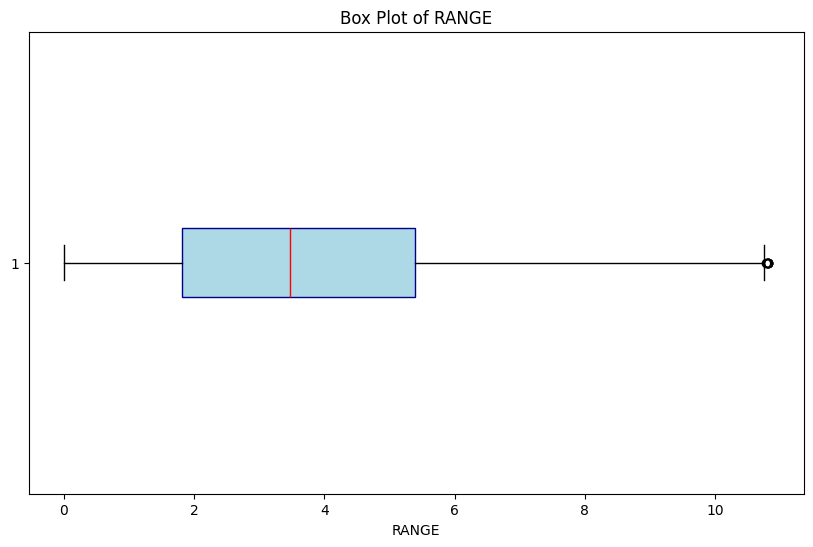

In [32]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    df_clean_filtered_RANGE["RANGE"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="darkblue"),
    medianprops=dict(color="red"),
)
plt.title("Box Plot of RANGE")
plt.xlabel("RANGE")
plt.show()

### **Feature Evaluation and Relationship Analysis**

#### **Feature Evaluation**
After having a better understanding of the features in the dataset using visualization, next we need to identify which features have the most impact on predicting the target variable. This allows us to focus on the most relevant features, improving model performance and interpretability.

We be using different technique:


##### **1. Correlation Matrix**

Firstly we be calculating the  **Correlation Matrix**, we will plot a heatmap to gain a better understanding of the relationships between different features. The heatmap below illustrates the correlation between each feature, with color intensity representing the strength of the relationship.

From the graph, we can observe that **RXPACC** has a strong positive correlation with **RANGE**, while **FP_AMP1**, **FP_AMP2**, and **FP_AMP3** show negative correlations with **RANGE**, indicating their potential influence on the target variable.

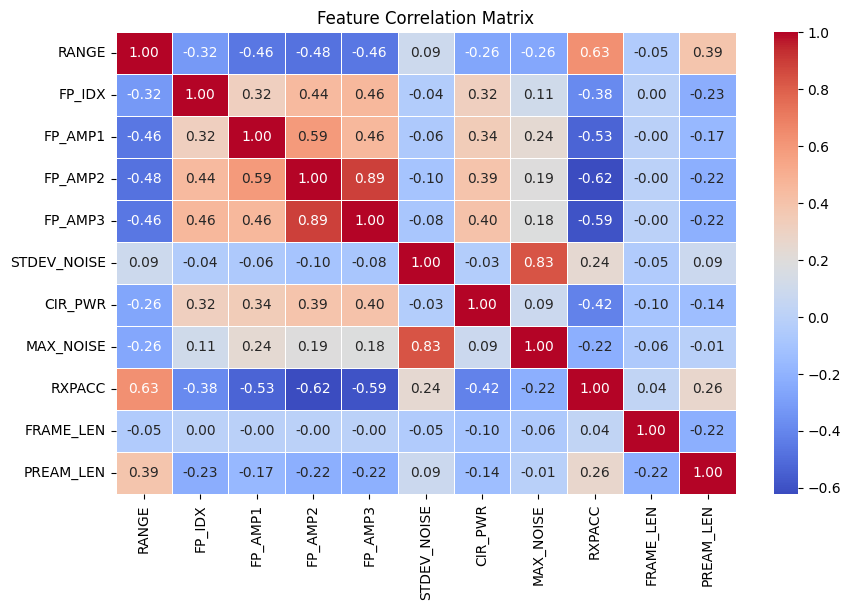

In [33]:
features = [
    "RANGE",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Compute correlation matrix
correlation_matrix = df_clean[features].corr()


# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

##### **2. Mutual Information**

Secondly, we will calculate the **Mutual Information** to assess the relationship between each feature and the target variable **RANGE**. We will plot a bar chart to visualize the mutual information scores where higher scores indicate more significant features for prediction.

From the graph, we can observe that **RXPACC** has the highest mutual information score  making it the most important feature for predicting **RANGE**. Other features such as **MAX_NOISE** and **CIR_PWR** also have notable scores  suggesting their relevance. On the other hand, **FRAME_LEN** has a low score which indicating that it might have less influence on the target variable.

In [34]:
# import libraries

try:
    from sklearn.feature_selection import mutual_info_regression

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


Mutual Information Scores (in descending order):
RXPACC         0.382571
MAX_NOISE      0.217761
CIR_PWR        0.181306
FP_AMP2        0.152645
FP_AMP1        0.150213
FP_AMP3        0.137412
STDEV_NOISE    0.112377
FP_IDX         0.082961
PREAM_LEN      0.075553
FRAME_LEN      0.007488
dtype: float64


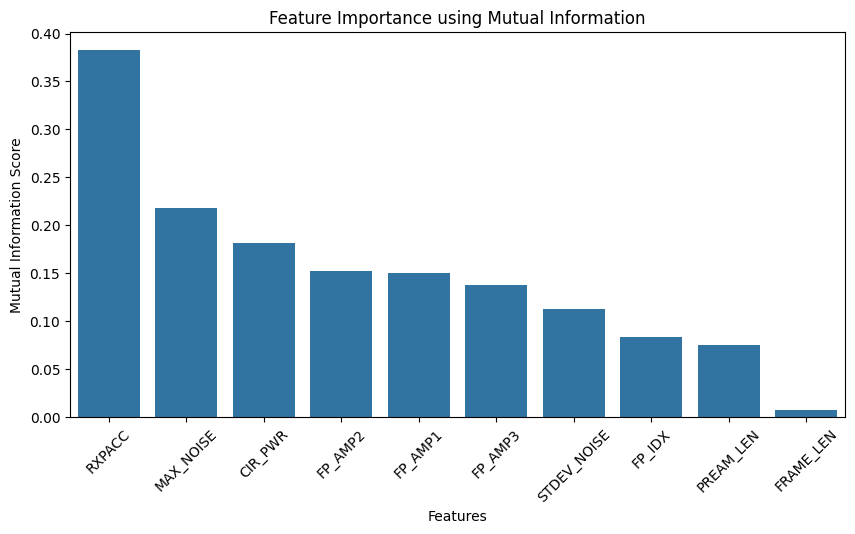

In [35]:
# mutual information => (to check the relationship between the features)

# Features
features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Define X as features set
X = df_clean[features]

# Define target variable
y = df_clean["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

# Plot the scores for better visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values)
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

##### **3. Normalization**

Thirdly, we performed **Normalization** using **MinMaxScaler** to scale feature values between **0 and 1**. The histogram below shows the distribution of scaled features, ensuring they fall within the same range.

Most features are **well-scaled**, but some may show **skewness** or **concentration** at one end, indicating the need for further transformations. The histogram also highlights potential **outliers** that could impact model performance.

Normalization helps ensure **equal contribution** of all features, improving the **accuracy** and **stability** of the classifier.

In [36]:
try:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


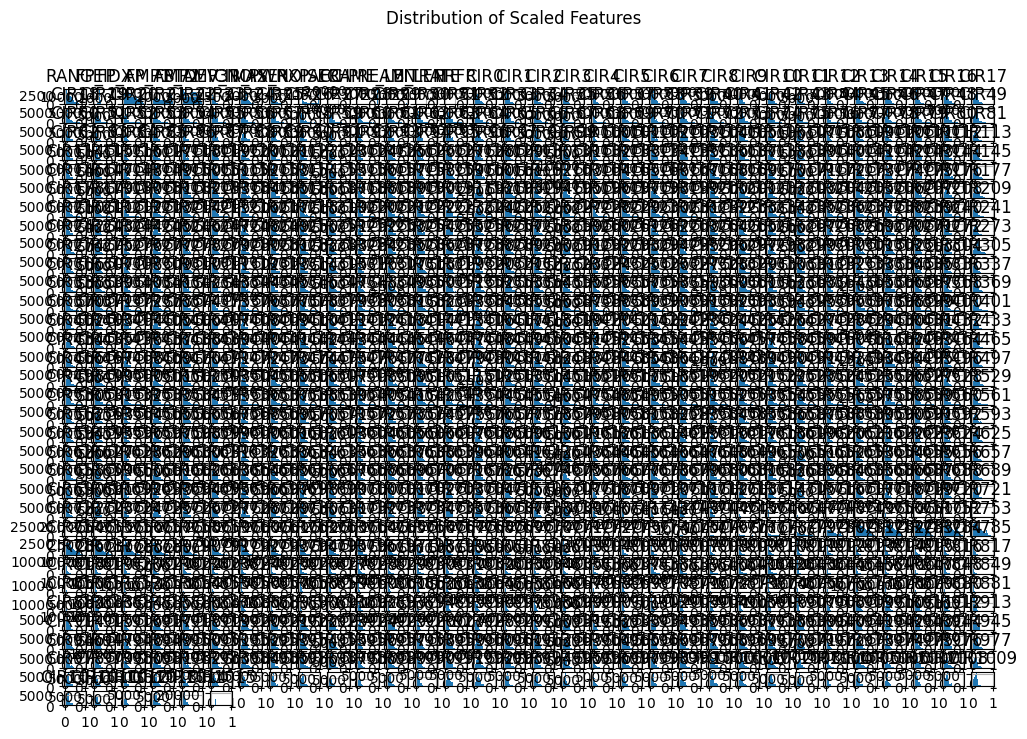

In [37]:
X = df_clean.drop(columns=["NLOS"])
y = df_clean["NLOS"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

# print("Scaled Training Data (First 10 rows):")
# print(X_train.head(10))

# print("\nScaled Test Data (First 10 rows):")
# print(X_test.head(10))


X_train.hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Scaled Features")
plt.show()

##### **4. Principal Component Analysis (PCA)**

Lastly, we performed **PCA** to reduce the number of CIR features while retaining key information. PCA transforms the original features into principal components, which capture the most important patterns in the data. The first 14 components explain 95% of the variance, with the 15th capturing the remaining variance. This reduces the dataset's complexity while preserving essential details for further analysis and modeling.

In [38]:
# Import  libraries

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


1. Selecting CIR Features from the Cleaned Data


In [39]:
# CIR Features List
cir_features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

X_cir = df_clean[cir_features]  # Extract relevant features from the DataFrame

2. Standardization of Data

In [40]:
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(
    X_cir
) 

3. Applying PCA

- To retain 95% of the variance by selecting the number of components.


In [41]:
pca = PCA(n_components=0.95)  # Retains enough components => 95% of the variance
X_cir_pca = pca.fit_transform(X_cir_scaled)

4. Checking the Shape of Transformed Data and Converting PCA Data to DataFrame

In [42]:
reduced_features = X_cir_pca.shape[1]
print(
    f"New shape after PCA: {X_cir_pca.shape} (Reduced to {reduced_features} components)"
)

pca_feature_names = [f"PCA_{i}" for i in range(reduced_features)]
df_pca = pd.DataFrame(X_cir_pca, columns=pca_feature_names)

df_clean = df_clean.drop(columns=cir_features).reset_index(drop=True)
df_clean = pd.concat([df_clean, df_pca], axis=1)

New shape after PCA: (42000, 8) (Reduced to 8 components)


5. Replacing Original Features with PCA Features

In [43]:
explained_variance_ratio = pca.explained_variance_ratio_  # value
cumulative_variance = np.cumsum(explained_variance_ratio)  # ratio

print("Explained Variance Ratio for each component:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_variance)

Explained Variance Ratio for each component: [0.36251239 0.18473292 0.11825062 0.07951557 0.07015036 0.06775219
 0.05697488 0.0453346 ]
Cumulative Explained Variance: [0.36251239 0.54724531 0.66549593 0.7450115  0.81516186 0.88291405
 0.93988893 0.98522353]


**Visualizing the Data**

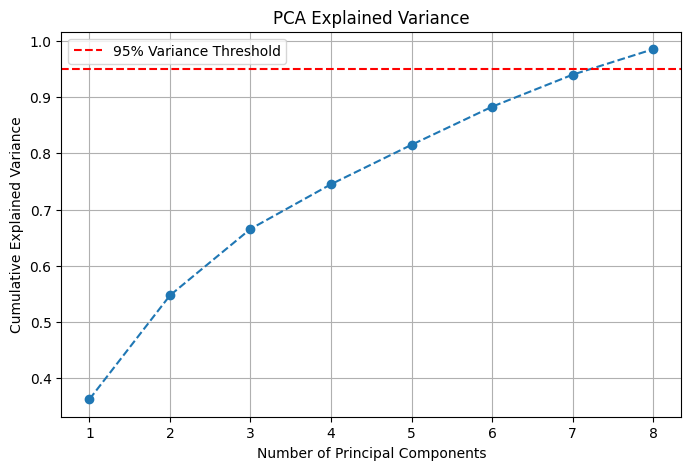

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linestyle="--",
)
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

#### **Data Minning**
After feature evaluation, we divide the dataset into training and test sets to train the model and assess its performance on unseen data.

In [45]:
# import libaries
try:
    from sklearn.model_selection import train_test_split
    import numpy as np

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


First, we split the dataset into training and testing sets to maintains the same structure but improves readability.

In [46]:


# Remove CIR columns => PCA already reduced them
df_clean = df_clean.loc[:, ~df_clean.columns.str.match(r"^CIR\d+$")]

# Remove low-importance features
low_mi_features = [
    "PRFR",
    "CH",
    "FRAME_LEN",
    "BITRATE",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
]
df_clean = df_clean.drop(columns=low_mi_features, errors="ignore")

# Combine FP_AMP columns => into one average (only if they exist)
fp_amp_cols = df_clean.filter(like="FP_AMP").columns  # Find all FP_AMP columns
if len(fp_amp_cols) > 0:
    df_clean["FP_AMP_AVG"] = df_clean[fp_amp_cols].mean(axis=1)
    df_clean = df_clean.drop(columns=fp_amp_cols, errors="ignore")

# Define features and target
X = df_clean.drop(columns=["NLOS"], errors="ignore")
y = df_clean["NLOS"]

# Split data into train and test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shape of the datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (33600, 9)
Shape of X_test: (8400, 9)
Shape of y_train: (33600,)
Shape of y_test: (8400,)


##### **Model Training and Tuning**
Training the model with data and tuning its settings to improve accuracy on new data.

In [47]:
# import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [48]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees in the forest
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],  # Split a node
    "min_samples_leaf": [1, 2, 4],  # Each leaf node
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

# Run the random search and tune hyperparameters
random_search.fit(X_train, y_train)

# Best model after hyperparameter tuning
best_rf_model = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


##### **Random Forest Hyperparameter Tuning with RandomizedSearchCV**

After training, let's evaluate the model using different metrics like accuracy, confusion matrix, and AUC score.

In [49]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees in the forest
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],  # split a node
    "min_samples_leaf": [1, 2, 4],  # each leaf node
}

# For faster hyperparameter tuning with RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

# Run the random search and tune hyperparameters
random_search.fit(X_train, y_train)

# Best model after hyperparameter tuning
best_rf_model = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


##### **Feature Importance**

First, we extract the feature importance from the trained RandomForest model, which indicates the contribution of each feature to the model’s predictions. We then store the feature names and their importance values in a DataFrame, sort them by importance, and display the top 20 most important features through a bar plot.

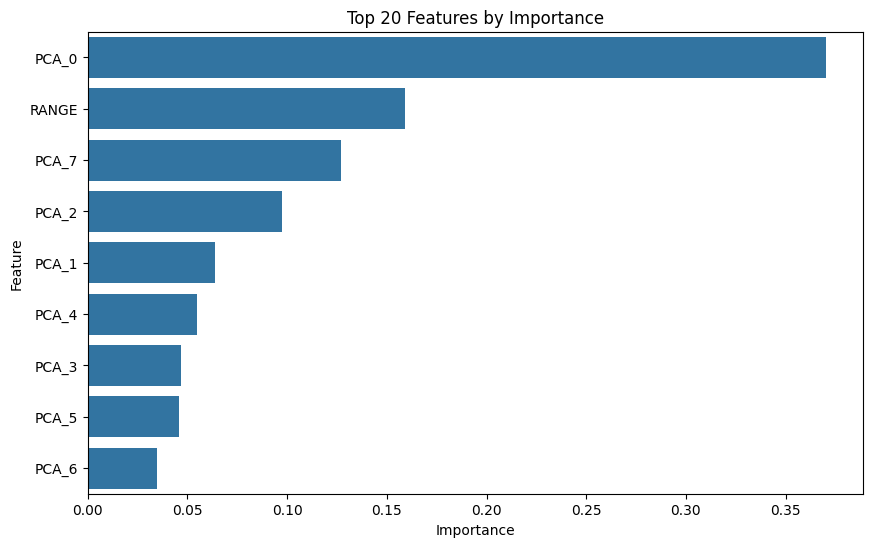

In [50]:
# Get feature importance =>  the trained RandomForest model
feature_importances = best_rf_model.feature_importances_

# Store feature names and importance values
feature_importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": feature_importances}
)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# Plot top 20 features by importance
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
plt.title("Top 20 Features by Importance")
plt.show()

##### **Model Evaluation**

After identifying important features, we use the model to predict the test data and evaluate its performance. The classification report provides key metrics like precision, recall, and F1-score

In [51]:
try:
    from sklearn.metrics import classification_report

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


##### **Model Evaluation on Test Data**

Now let's evaluate the model on the test dataset to see how it performs on unseen data.

In [52]:
# Predict on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate the model's performance on the test set
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      4252
         1.0       0.93      0.89      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      4252
         1.0       0.93      0.89      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



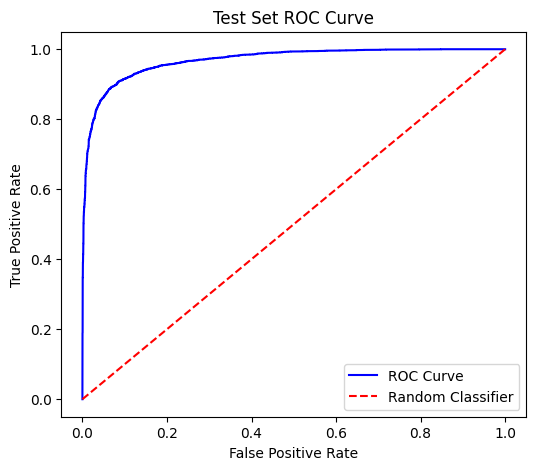

In [53]:
from sklearn.metrics import classification_report, roc_curve
import matplotlib.pyplot as plt

#  model predictions on the test set
y_test_pred = best_rf_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

# AUC ROC curve => Receiver Operating Characteristic curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Plot graph
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="b", label="ROC Curve")
plt.plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
plt.show()

#### **Final Model Deployment**

After selecting and evaluating the best model, we save the trained model, scaler, and PCA for future use and easy 

In [54]:
try:
    import joblib

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


##### **Saving the Model and Preprocessing Steps**
Once the best model is trained and evaluated, we save the model, scaler, and PCA transformations for future use. This allows you to load and apply them to new data without needing to retrain or reprocess.

In [55]:
# Save the Random Forest model
joblib.dump(best_rf_model, "best_rf_model.pkl")

# Save the scaler for future transformations
joblib.dump(scaler, "scaler.pkl")

# Save the PCA model
joblib.dump(pca, "pca_model.pkl")
print(
    "Model and preprocessing steps saved as best_rf_model.pkl, scaler.pkl, and pca_model.pkl"
)

Model and preprocessing steps saved as best_rf_model.pkl, scaler.pkl, and pca_model.pkl


Next, calculate the accuracy and ROC AUC of the trained  model on the test set and save the evaluation results into a text file

In [59]:
try:
    import os
    import joblib
    from sklearn.metrics import accuracy_score, roc_auc_score

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [ ]:
# Calculate accuracy and ROC AUC
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Create the 'model_outputs' folder if it doesn't exist
os.makedirs("model_outputs", exist_ok=True)

# Save evaluation results to a text file under the 'model_outputs' folder
with open("model_outputs/model_evaluation.txt", "w") as f:
    f.write(f"Best Hyperparameters: {best_rf_model.get_params()}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"ROC AUC: {roc_auc:.4f}\n")


Evaluation results saved as model_outputs/model_evaluation.txt
Model and preprocessing steps saved as best_rf_model.pkl, scaler.pkl, and pca_model.pkl in 'model_outputs' folder


##### **Saving files to Local Folder**

Next, it saves the model evaluation results (accuracy and ROC AUC) along with the trained Random Forest model, scaler, and PCA transformations into files for future use in the **'model_outputs'** folder.

In [ ]:
# Calculate accuracy and ROC AUC
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Save evaluation results to a text file under the 'model_outputs' folder
os.makedirs("model_outputs", exist_ok=True)
with open("model_outputs/model_evaluation.txt", "w") as f:
    f.write(f"Best Hyperparameters: {best_rf_model.get_params()}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"ROC AUC: {roc_auc:.4f}\n")

print("Evaluation results saved as model_outputs/model_evaluation.txt")

Finally, Train models are then saved in csv under **'trained_model_outputs'** folder

In [58]:
# create folder
os.makedirs("trained_model_outputs", exist_ok=True)  # Folder name

# Save the training and test data splits to CSV files
X_train.to_csv("trained_model_outputs/X_train.csv", index=False)  # training set
X_test.to_csv("trained_model_outputs/X_test.csv", index=False)  # testing set

# Save the 'NLOS' variable => for the training and testing sets
y_train.to_csv("trained_model_outputs/y_train.csv", index=False)
y_test.to_csv("trained_model_outputs/y_test.csv", index=False)

print("Data splits saved as CSV files in 'trained_model_outputs' folder")

Data splits saved as CSV files in 'trained_model_outputs' folder
